In [27]:
%load_ext autoreload
%autoreload 2

# for src folder access
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import os
import pandas as pd
from IPython.utils import io
from matplotlib import pyplot as plt

from src.config import DEFAULT_DATA_ROOT, TRIMMED_DATA_ROOT, ACTIVE_SECTIONS_DATA_ROOT
from src.clap_sync import accel_mag_from_df, final_sync_fix

DEFAULT_DATA_ROOT

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'C:\\Users\\blue_\\Desktop\\git-repos\\HAR_Projekt\\ax6_cnn_project\\data\\raw'

In [2]:
filenames = os.listdir(TRIMMED_DATA_ROOT)
filenames

['12left.csv',
 '12right.csv',
 '13left.csv',
 '13right.csv',
 '14left.csv',
 '14right.csv',
 '15left.csv',
 '15right.csv',
 '16left.csv',
 '16right.csv',
 '17left.csv',
 '17right.csv',
 '18left.csv',
 '18right.csv',
 '19left.csv',
 '19right.csv',
 '20left.csv',
 '20right.csv',
 '21left.csv',
 '21right.csv']

In [3]:
dfs = []
dfs_ = []
for filename in filenames:
    dfs_.append(pd.read_csv(os.path.join(TRIMMED_DATA_ROOT, filename)))
    if len(dfs_) == 2:
        dfs.append(dfs_)
        dfs_ = []

dfs[0][0]

,t,ax,ay,az,gx,gy,gz,acc_mag
0,0 days 00:00:53.790000,0.323486,-1.076416,-0.264160,162.261948,159.736633,-66.398621,1.154597
1,0 days 00:00:53.800000,0.399902,-0.992676,-0.391602,122.161858,156.684875,-34.690857,1.139596
2,0 days 00:00:53.810000,0.513672,-0.974854,-0.498779,72.128296,143.760681,-9.841919,1.209537
3,0 days 00:00:53.820000,0.530762,-0.925781,-0.541504,35.545349,121.025078,1.525879,1.196664
4,0 days 00:00:53.830000,0.496826,-0.868164,-0.515625,15.197753,101.226799,11.238097,1.125351
...,...,...,...,...,...,...,...,...
12814,0 days 00:03:01.930000,0.090576,-0.829102,-0.423584,5.538940,-51.925655,-23.628233,0.935434
12815,0 days 00:03:01.940000,0.068359,-0.860596,-0.434814,3.410339,-53.649899,-24.971006,0.966624
12816,0 days 00:03:01.950000,0.037354,-0.885742,-0.452881,0.022888,-53.047176,-24.841307,0.995508
12817,0 days 00:03:01.960000,0.025391,-0.890381,-0.476563,-2.761841,-51.010128,-22.903440,1.010215


In [4]:
for dfL, dfR in dfs:
    dfL["acc_mag"] = accel_mag_from_df(dfL)
    dfR["acc_mag"] = accel_mag_from_df(dfR)

Synchronisations-Punkt: L=178, R=120 | Offset: -58


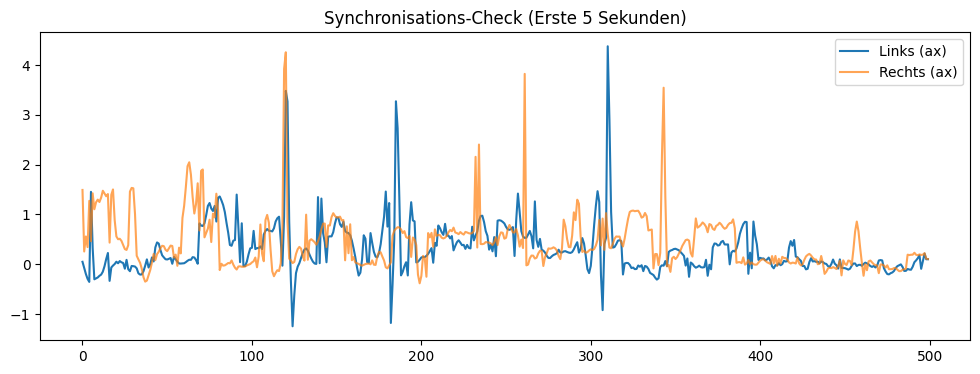

Synchronisations-Punkt: L=258, R=186 | Offset: -72


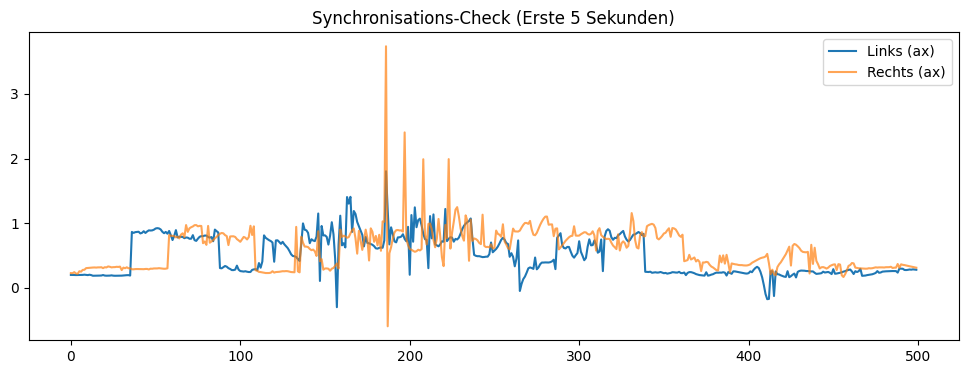

Synchronisations-Punkt: L=311, R=125 | Offset: -186


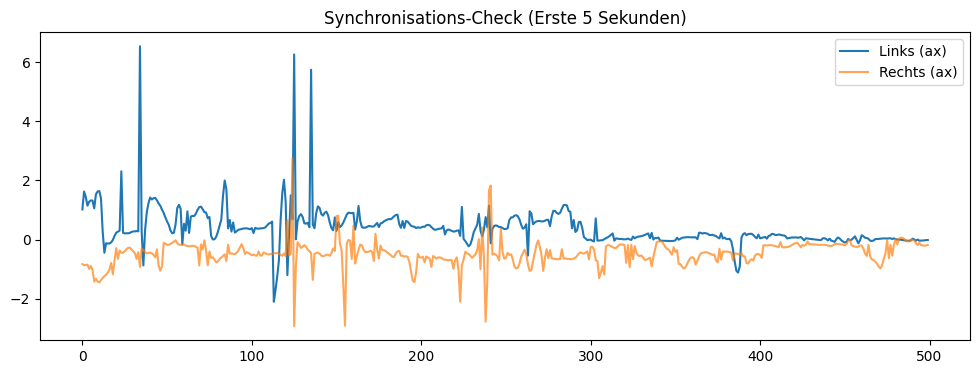

Synchronisations-Punkt: L=139, R=130 | Offset: -9


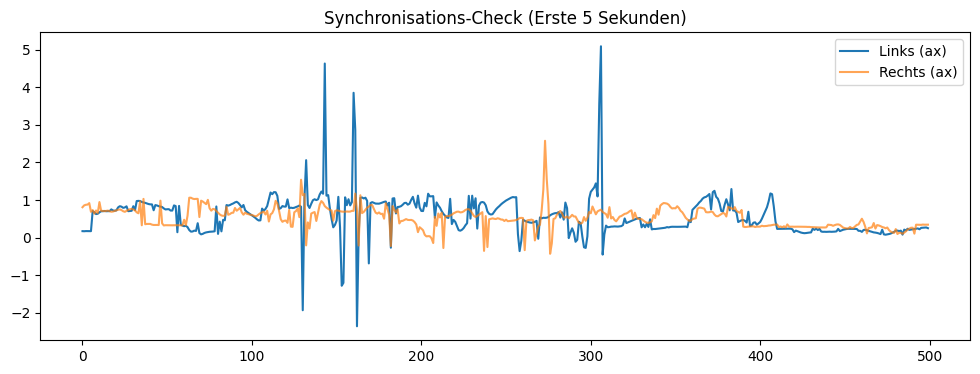

Synchronisations-Punkt: L=175, R=42 | Offset: -133


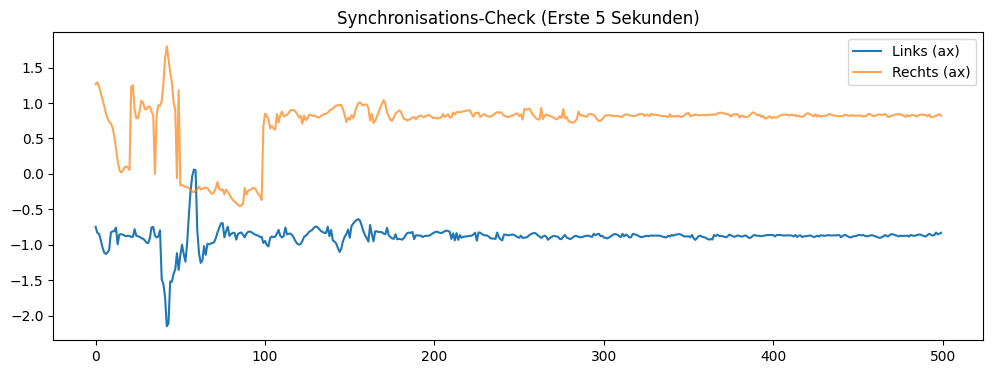

Synchronisations-Punkt: L=328, R=229 | Offset: -99


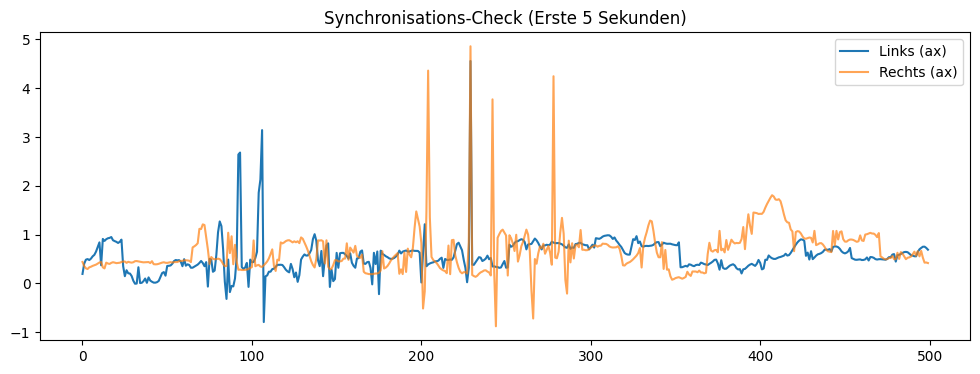

Synchronisations-Punkt: L=191, R=216 | Offset: 25


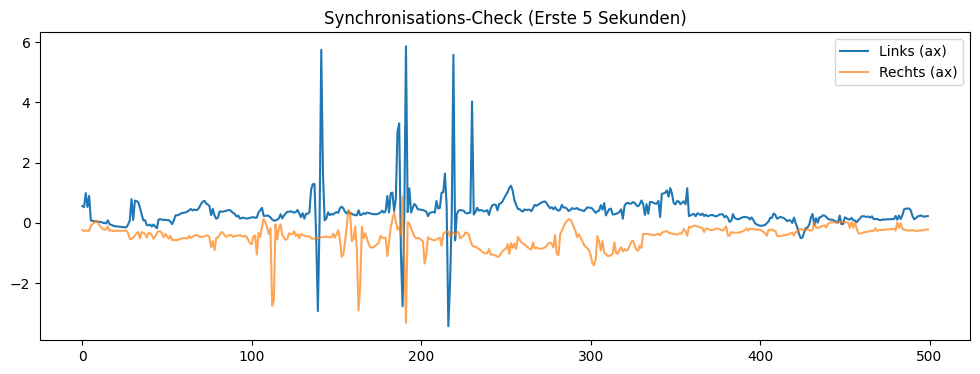

Synchronisations-Punkt: L=328, R=176 | Offset: -152


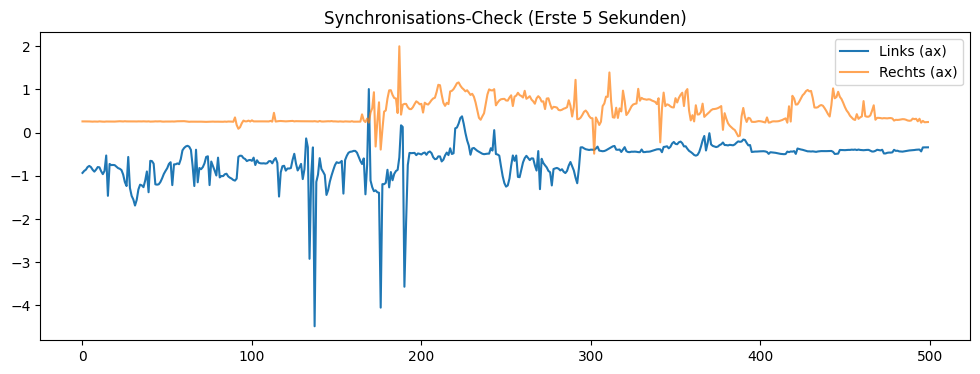

Synchronisations-Punkt: L=179, R=297 | Offset: 118


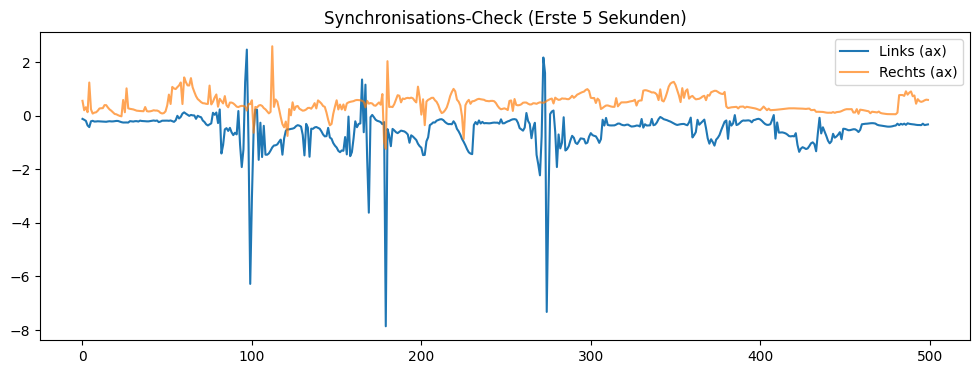

Synchronisations-Punkt: L=181, R=279 | Offset: 98


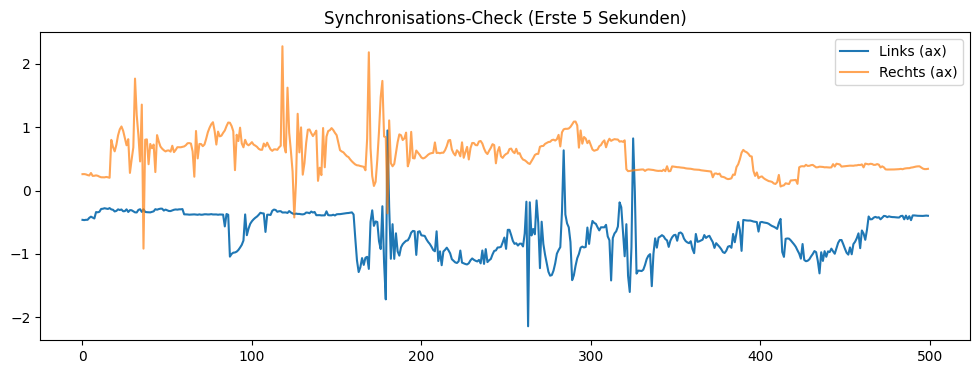

In [5]:
dfs_synced = [final_sync_fix(dfL, dfR) for dfL, dfR in dfs]

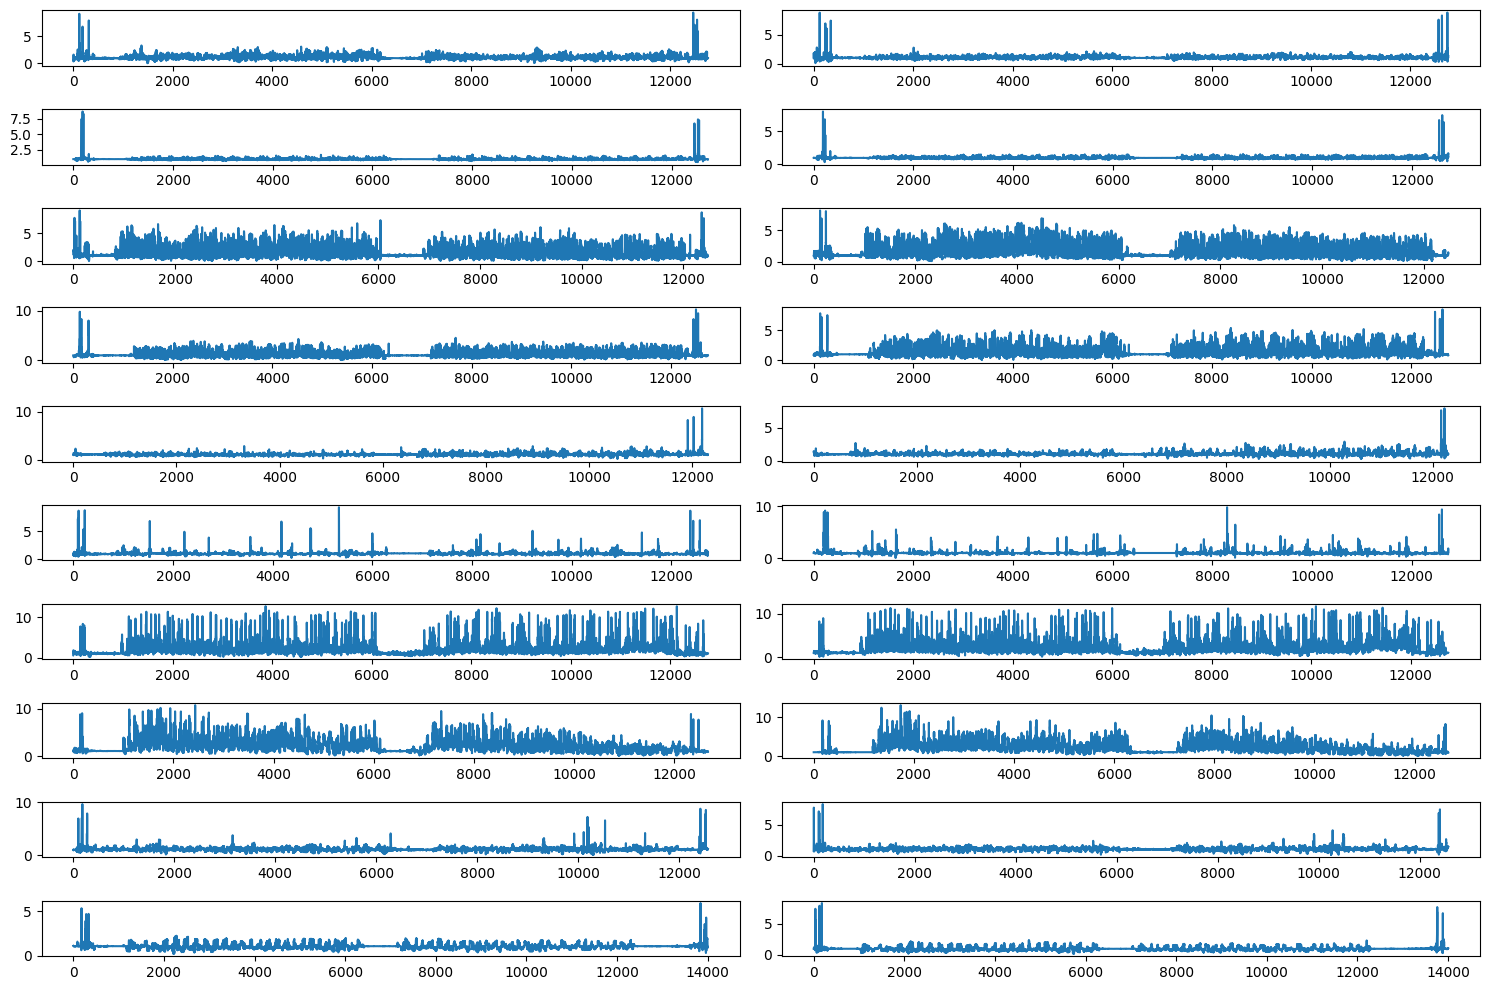

In [6]:
fig, ax = plt.subplots(10, 2, figsize=(15, 10))
for (ax1, ax2), (dfL, dfR) in zip(ax, dfs_synced):
    dfL["acc_mag"].plot(ax=ax1)
    dfR["acc_mag"].plot(ax=ax2)

plt.tight_layout()

In [30]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

class FourLineCutter:
    def __init__(self, dfL, dfR, exercise_id):
        self.dfL = dfL
        self.dfR = dfR
        self.feature_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
        
        self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(15, 4), sharex=True)
        
        # Hintergründe plotten
        self.ax1.plot(dfL.index, dfL["acc_mag"], color="royalblue", lw=1, label="Links")
        self.ax2.plot(dfR.index, dfR["acc_mag"], color="darkorange", lw=1, label="Rechts")
        
        self.ax1.set_title(f"High-Speed Cutting: {exercise_id}")
        self.ax1.legend()

        # Initiale Positionen
        idx = dfL.index
        pos = [idx[int(len(idx)*p)] for p in [0.1, 0.2, 0.7, 0.8]]
        
        self.lines = []
        self.active_line = None
        
        # 4 Linien-Paare erstellen (immer 2 pro Zeitpunkt: eine oben, eine unten)
        # Wir speichern sie als Paare, um sie später synchronisieren zu können
        colors = ['red', 'red', 'green', 'green']
        self.line_pairs = []
        
        for p, col in zip(pos, colors):
            l1 = self.ax1.axvline(p, color=col, lw=2, picker=10)
            l2 = self.ax2.axvline(p, color=col, lw=2, picker=10)
            self.line_pairs.append([l1, l2])
            self.lines.extend([l1, l2])

        # Event-Binding
        self.fig.canvas.mpl_connect('pick_event', self.on_pick)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)

        plt.tight_layout()
        
        # Blitting-Vorbereitung: Hintergrund speichern
        self.bg = None
        self.fig.canvas.draw()

    def on_pick(self, event):
        if event.artist in self.lines:
            self.active_line = event.artist
            # Den Hintergrund ohne die Linien "einfrieren" für flüssiges Ziehen
            # (In Jupyter/Widget manchmal schwierig, daher nutzen wir hier die simple Variante,
            # reduzieren aber die Redraw-Last)

    def on_motion(self, event):
        if self.active_line and event.xdata is not None:
            # Nur die aktuell gezogene Linie updaten
            self.active_line.set_xdata([event.xdata, event.xdata])
            # draw_idle ist effizienter als draw()
            self.fig.canvas.draw_idle() 

    def on_release(self, event):
        if self.active_line:
            curr_x = self.active_line.get_xdata()
            # Partner finden und nachziehen (nach dem Loslassen)
            for pair in self.line_pairs:
                if self.active_line in pair:
                    pair[0].set_xdata(curr_x)
                    pair[1].set_xdata(curr_x)
            
            self.active_line = None
            self.fig.canvas.draw_idle()

    def get_data(self):
        # Positionen extrahieren
        x_red = sorted([self.line_pairs[0][0].get_xdata()[0], self.line_pairs[1][0].get_xdata()[0]])
        x_green = sorted([self.line_pairs[2][0].get_xdata()[0], self.line_pairs[3][0].get_xdata()[0]])
        
        def cut(range_x):
            s, e = range_x
            # Nutze .loc für schnelles Slicing
            cL = self.dfL.loc[s:e, self.feature_cols]
            cR = self.dfR.loc[s:e, self.feature_cols]
            combined = pd.concat([cL, cR], axis=1, join='inner')
            return combined

        return cut(x_red), cut(x_green)


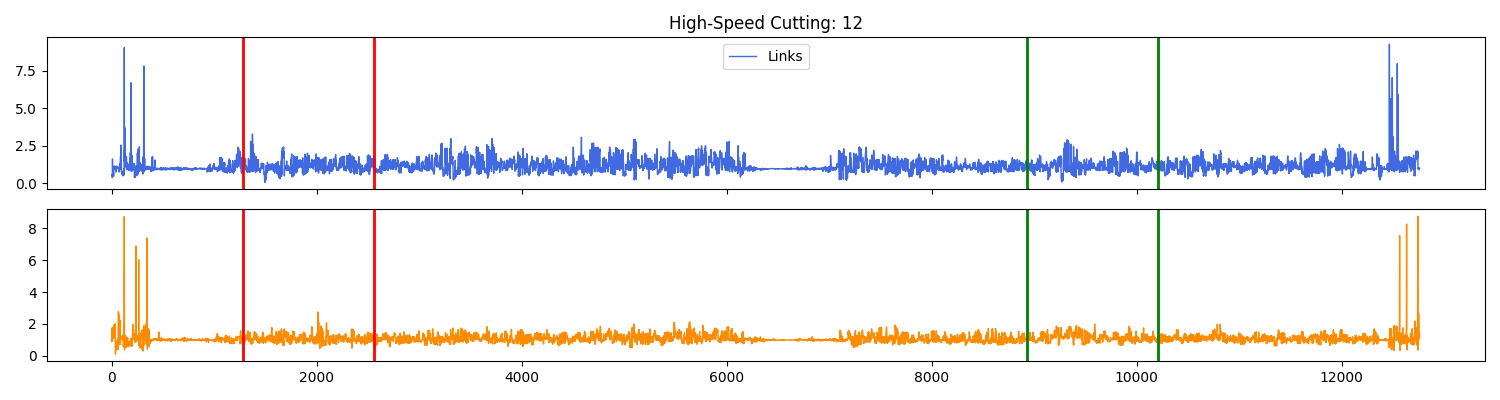

In [31]:
c0 = FourLineCutter(*dfs_synced[0], 12)

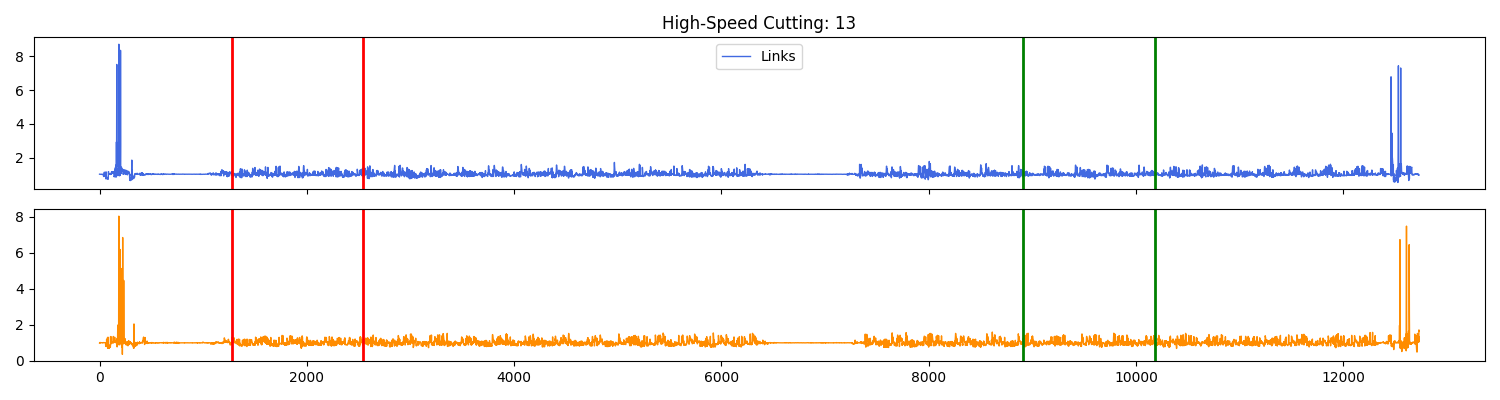

In [32]:
c1 = FourLineCutter(*dfs_synced[1], 13)

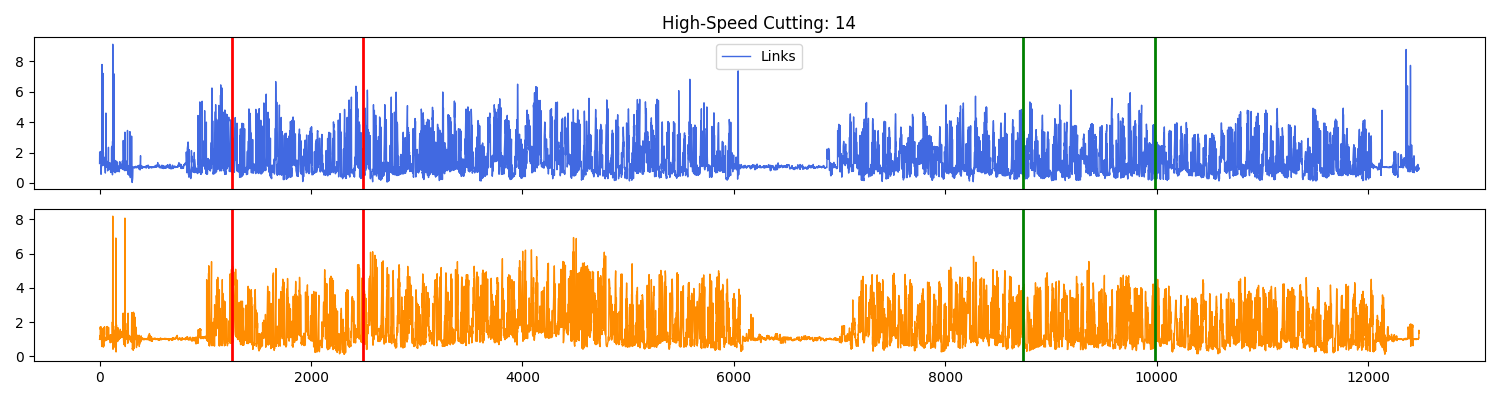

In [33]:
c2 = FourLineCutter(*dfs_synced[2], 14)

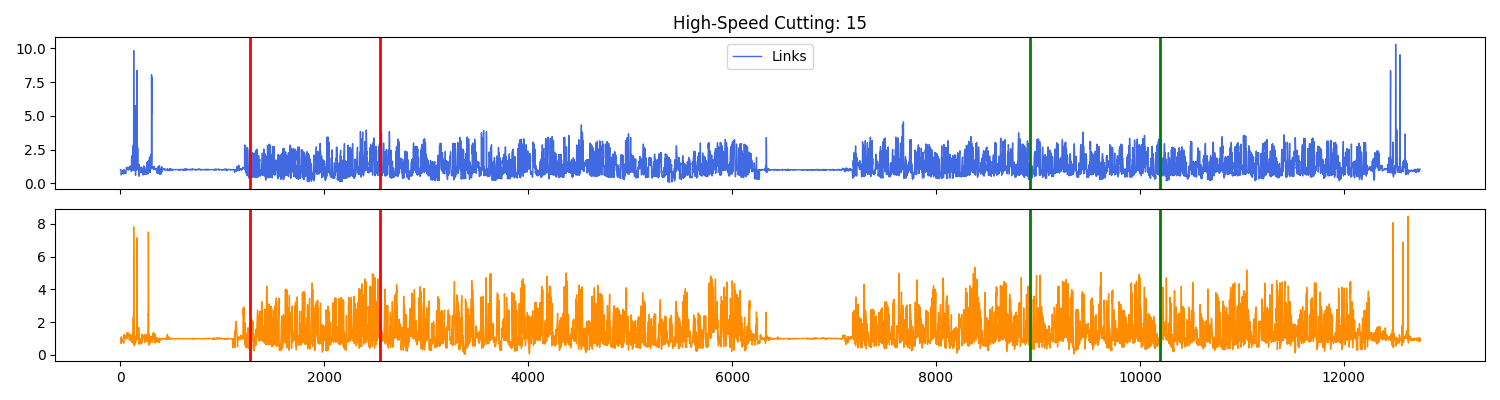

In [34]:
c3 = FourLineCutter(*dfs_synced[3], 15)

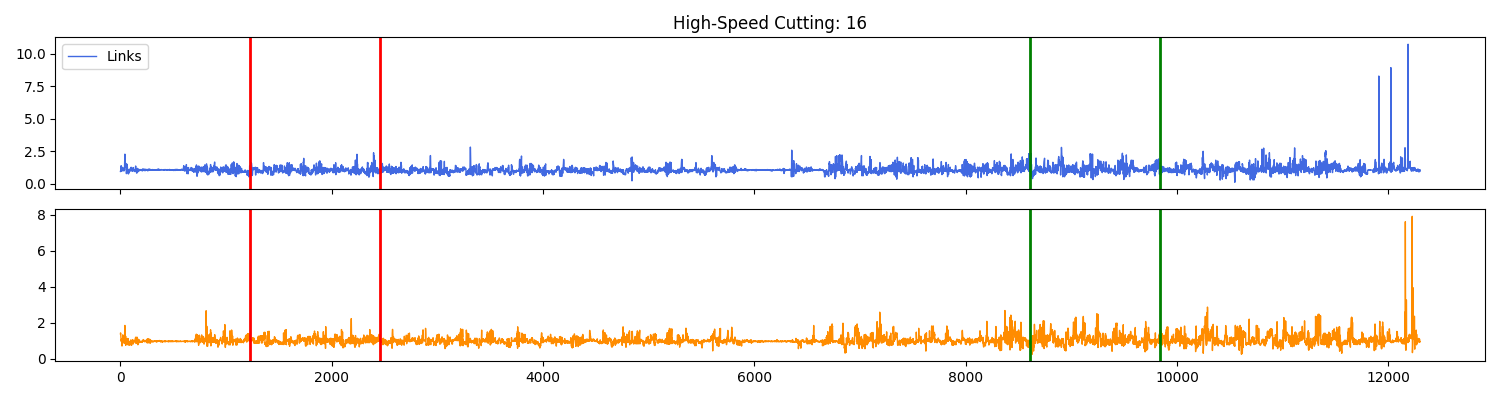

In [35]:
c4 = FourLineCutter(*dfs_synced[4], 16)

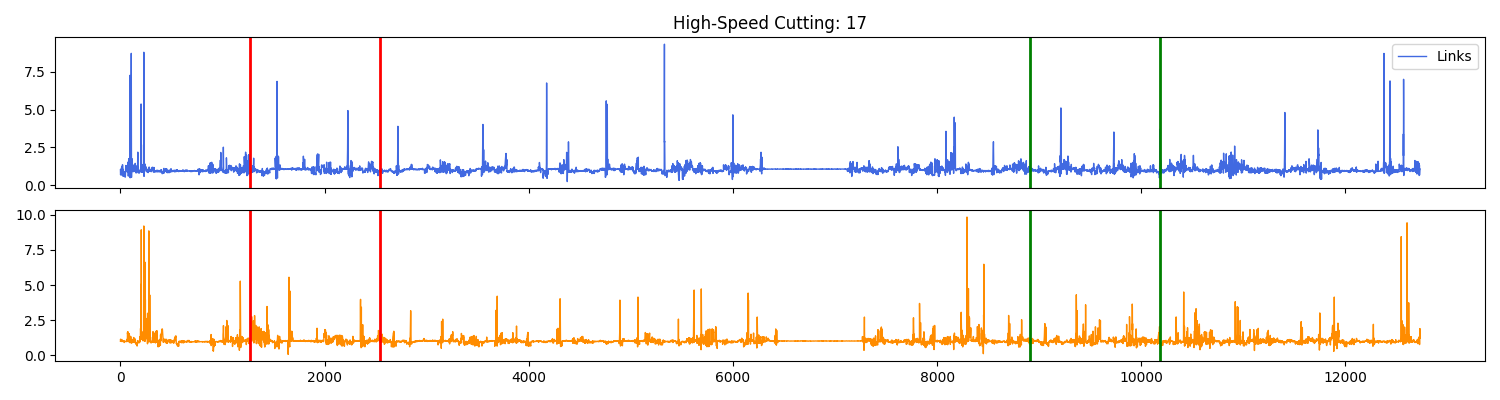

In [36]:
c5 = FourLineCutter(*dfs_synced[5], 17)

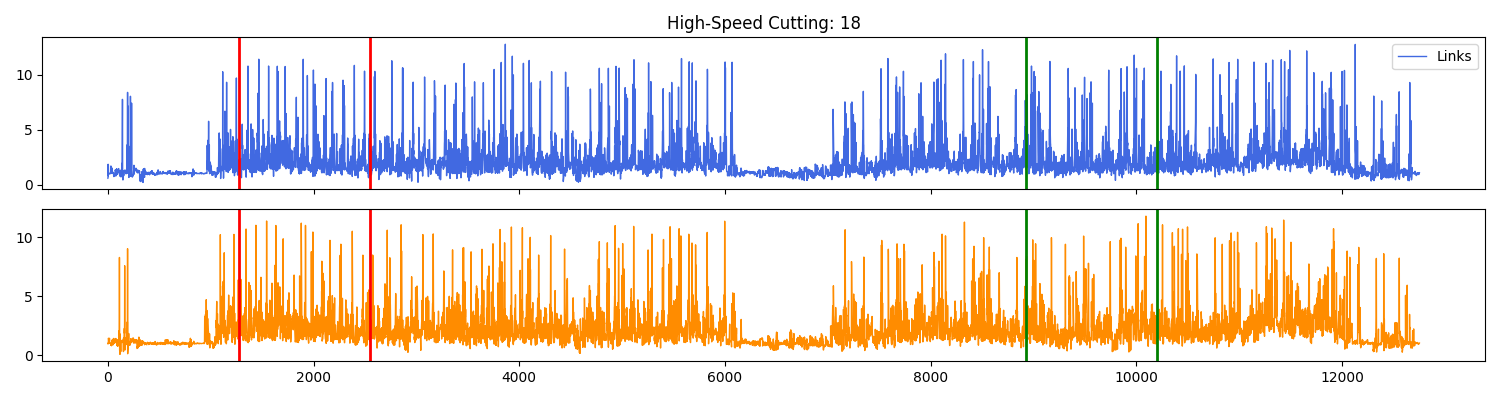

In [37]:
c6 = FourLineCutter(*dfs_synced[6], 18)

C:\Users\blue_\AppData\Local\Temp\ipykernel_23048\1100502938.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(15, 4), sharex=True)


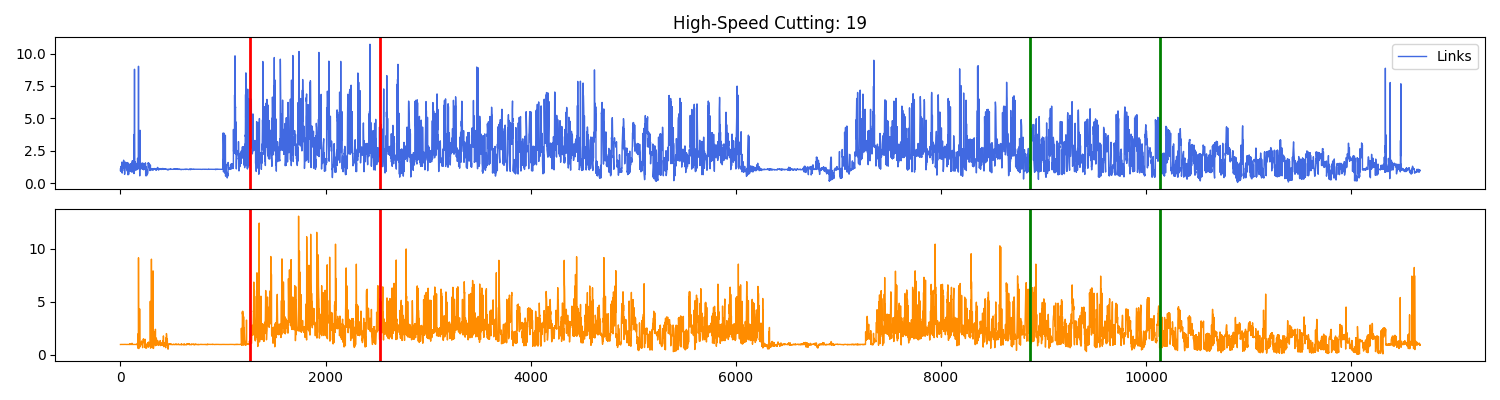

In [38]:
c7 = FourLineCutter(*dfs_synced[7], 19)

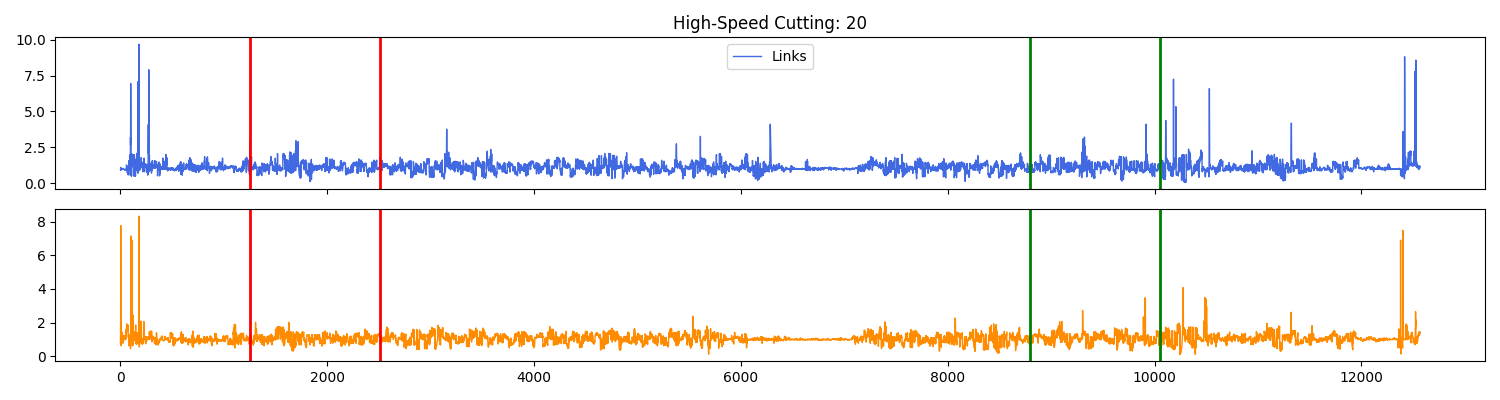

In [39]:
c8 = FourLineCutter(*dfs_synced[8], 20)

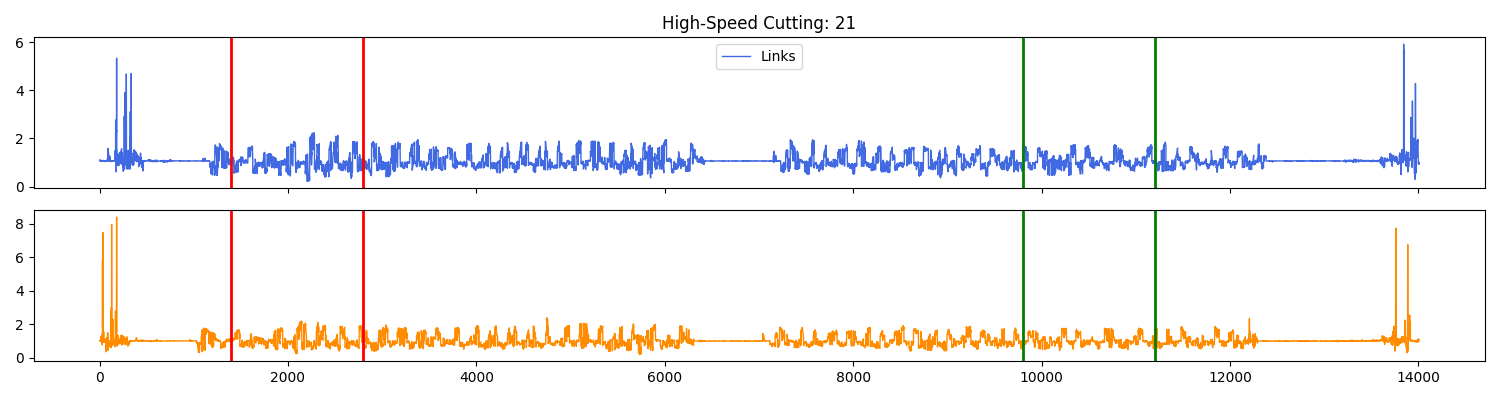

In [40]:
c9 = FourLineCutter(*dfs_synced[9], 21)

In [43]:
cutters = [c0, c1, c2, c3, c4, c5, c6, c7, c8, c9]
tensors = [c.get_data() for c in cutters]

In [44]:
if not os.path.exists(ACTIVE_SECTIONS_DATA_ROOT):
    os.mkdir(ACTIVE_SECTIONS_DATA_ROOT)
    
if len(os.listdir(ACTIVE_SECTIONS_DATA_ROOT)) == 0:
    for (t1, t2), id in zip(tensors, range(12, 22)):
        _path = os.path.join(ACTIVE_SECTIONS_DATA_ROOT, str(id))
        t1.to_csv(_path + "part1.csv", index=False)
        t2.to_csv(_path + "part2.csv", index=False)